In [1]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import os

# scifact
# arguana
# nfcorpus
# scidocs
# fiqa

def data_loader(dataset: str):
    url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"
    data_path = util.download_and_unzip(url, "data")

    corpus_path = os.path.join(data_path, "corpus.jsonl")
    queries_path = os.path.join(data_path, "queries.jsonl")
    qrels_path = os.path.join(data_path, "qrels", "test.tsv")

    corpus, queries, qrels = GenericDataLoader(
        corpus_file=corpus_path,
        query_file=queries_path,
        qrels_file=qrels_path
    ).load_custom()
    return corpus, queries, qrels


c:\Users\Axel\Desktop\lsa rocchio knn\BEIR_lsa_rocchio_knn\venv\Lib\site-packages\beir\util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
import spacy

nlp = spacy.load("en_core_web_sm")

def tokenize(s):
    s = nlp(s)
    tokens = [token.text.lower()
              for token in s
              if not token.is_punct and not token.is_stop and not token.is_space]
    return tokens

def clean_data(corpus: dict, queries: dict):
    cleaned_corpus = {}
    for doc_id, doc in corpus.items():
        title = doc.get("title", "")
        text = doc.get("text", "")
        full_text = title + " " + text
        tokens = tokenize(full_text)
        cleaned_corpus[doc_id] = {"text": " ".join(tokens)}

    cleaned_queries = {}
    for query_id, query_text in queries.items():
        tokens = tokenize(query_text)
        cleaned_queries[query_id] = {"text": " ".join(tokens)}

    return cleaned_corpus, cleaned_queries

In [6]:
corpus, queries, qrels = data_loader("arguana")
cleaned_corpus, cleaned_queries = clean_data(corpus, queries)

100%|██████████| 8674/8674 [00:00<00:00, 187303.17it/s]


In [7]:
import sys
import os

project_root = r'c:\Users\Axel\Desktop\lsa rocchio knn\BEIR_lsa_rocchio_knn'
sys.path.append(project_root)

from src.models.lsa import LSAModel

In [8]:
vocab_size = len(set(word for doc in cleaned_corpus.values() for word in doc["text"].split()))
print("Taille du vocabulaire :", vocab_size)

Taille du vocabulaire : 37158


In [11]:
from beir.retrieval.evaluation import EvaluateRetrieval

def evaluate_model(model, queries, qrels, k_values=[10, 100]):
    results = {}
    max_k = max(k_values)

    for qid in qrels:
        if qid not in queries:
            continue
        query_text = queries[qid]["text"]
        scores = model.search(query_text, top_k=max_k)
        results[qid] = {doc_id: float(score) for doc_id, score in scores}

    ndcg, _map, recall, precision = EvaluateRetrieval.evaluate(qrels, results, k_values=k_values)
    return (ndcg, _map, recall, precision)



[INFO] k retenu par méthode elbow : 320


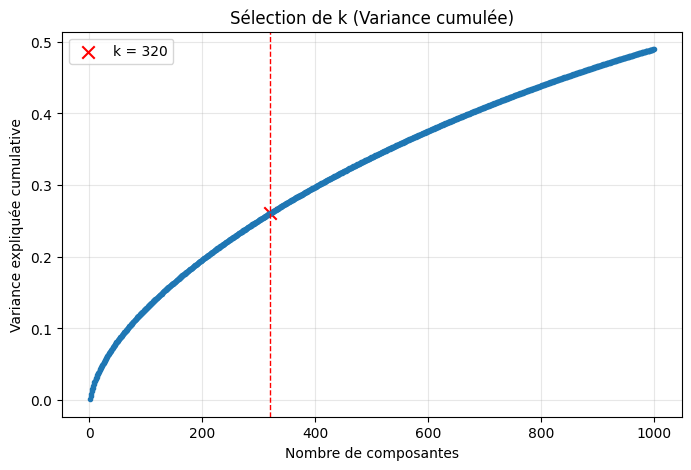

[INFO] Animation saved: elbow.gif
[INFO] k retenu par variance cumulative : 700 (≥ 90% variance)


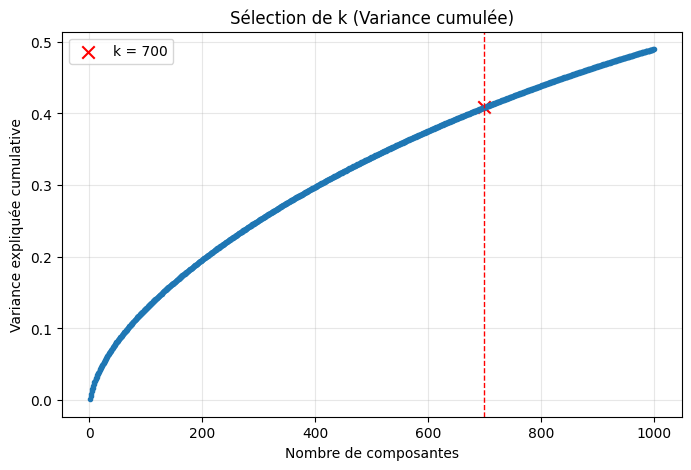

In [9]:
#from src.models.bm25 import BM25Model
from src.models.lsa import LSAModel

'''
bm25 = BM25Model()
bm25.fit(cleaned_corpus)
print("bm25 chargé")
'''

lsa = LSAModel()
lsa.fit(cleaned_corpus, elbow=True, plot=True, gif=True)


lsa_rocchio = LSAModel()
lsa_rocchio.fit(cleaned_corpus, variance_cum=True, plot=True)

In [12]:
print(evaluate_model(lsa, cleaned_queries, qrels))

({'NDCG@10': 0.49985, 'NDCG@100': 0.54286}, {'MAP@10': 0.40512, 'MAP@100': 0.41561}, {'Recall@10': 0.80441, 'Recall@100': 0.98862}, {'P@10': 0.08044, 'P@100': 0.00989})


In [ ]:
models = [bm25, lsa, lsa_rocchio, lsa_knn]
for model in models:
    res = evaluate_model(model, cleaned_queries, qrels)
    print(f'{model}:\nNDGC@10: {res[0]["NDCG@10"]}, Recall@100: {res[2]["Recall@100"]}')